In [1]:
# ==========================================
# 1. Install Libraries
# ==========================================
!pip install pandas scikit-learn

# ==========================================
# 2. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 3. Sample Job Description
# ==========================================
job_description = """
Looking for a Python Developer with experience in machine learning,
data analysis, SQL, and problem-solving skills. Knowledge of NLP,
deep learning, and APIs is a plus.
"""

# Extract required skills manually (can improve later)
required_skills = [
    "python", "machine learning", "data analysis",
    "sql", "nlp", "deep learning", "api"
]

# ==========================================
# 4. Sample Resumes
# ==========================================
resumes = [
    "Python developer with experience in machine learning and data analysis using pandas and numpy",
    "Frontend developer skilled in HTML CSS JavaScript and React",
    "Data analyst with SQL Python and visualization skills",
    "Machine learning engineer with deep learning NLP and API experience",
    "Software engineer with Java C++ and problem solving skills"
]

resume_names = [
    "Candidate A",
    "Candidate B",
    "Candidate C",
    "Candidate D",
    "Candidate E"
]

# ==========================================
# 5. Text Cleaning Function
# ==========================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

cleaned_resumes = [clean_text(r) for r in resumes]
cleaned_job = clean_text(job_description)

# ==========================================
# 6. TF-IDF Vectorization
# ==========================================
vectorizer = TfidfVectorizer()

all_docs = cleaned_resumes + [cleaned_job]
tfidf_matrix = vectorizer.fit_transform(all_docs)

# ==========================================
# 7. Similarity Calculation
# ==========================================
job_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(resume_vectors, job_vector)

# ==========================================
# 8. Skill Matching Function
# ==========================================
def skill_match(resume, skills):
    matched = []
    missing = []

    for skill in skills:
        if skill in resume:
            matched.append(skill)
        else:
            missing.append(skill)

    return matched, missing

# ==========================================
# 9. Ranking Candidates
# ==========================================
results = []

for i, resume in enumerate(cleaned_resumes):
    score = similarity_scores[i][0]
    matched, missing = skill_match(resume, required_skills)

    results.append({
        "Name": resume_names[i],
        "Score": round(score * 100, 2),
        "Matched Skills": matched,
        "Missing Skills": missing
    })

# Sort by score
results = sorted(results, key=lambda x: x["Score"], reverse=True)

# ==========================================
# 10. Display Results
# ==========================================
print("\n===== RESUME RANKING =====\n")

for r in results:
    print(f"Candidate: {r['Name']}")
    print(f"Match Score: {r['Score']}%")
    print(f"Matched Skills: {r['Matched Skills']}")
    print(f"Missing Skills: {r['Missing Skills']}")
    print("-" * 50)

# ==========================================
# 11. Optional: Convert to DataFrame
# ==========================================
df_results = pd.DataFrame(results)
print("\nTop Candidates:\n")
print(df_results.head())



===== RESUME RANKING =====

Candidate: Candidate A
Match Score: 47.41%
Matched Skills: ['python', 'machine learning', 'data analysis']
Missing Skills: ['sql', 'nlp', 'deep learning', 'api']
--------------------------------------------------
Candidate: Candidate D
Match Score: 46.91%
Matched Skills: ['machine learning', 'nlp', 'deep learning', 'api']
Missing Skills: ['python', 'data analysis', 'sql']
--------------------------------------------------
Candidate: Candidate C
Match Score: 31.38%
Matched Skills: ['python', 'sql']
Missing Skills: ['machine learning', 'data analysis', 'nlp', 'deep learning', 'api']
--------------------------------------------------
Candidate: Candidate B
Match Score: 12.26%
Matched Skills: []
Missing Skills: ['python', 'machine learning', 'data analysis', 'sql', 'nlp', 'deep learning', 'api']
--------------------------------------------------
Candidate: Candidate E
Match Score: 11.63%
Matched Skills: []
Missing Skills: ['python', 'machine learning', 'data an

## **system**


=== RANKING ===

  Name  Score  Matched  Missing                             Matched Skills  \
0    A  67.94        3        4  [python, machine learning, data analysis]   
1    D  41.44        3        4                  [nlp, deep learning, api]   
2    C  32.34        2        5                              [python, sql]   
3    B  12.38        0        7                                         []   
4    E   8.49        0        7                                         []   

                                      Missing Skills  
0                     [sql, nlp, deep learning, api]  
1     [python, machine learning, data analysis, sql]  
2  [machine learning, data analysis, nlp, deep le...  
3  [python, machine learning, data analysis, sql,...  
4  [python, machine learning, data analysis, sql,...  


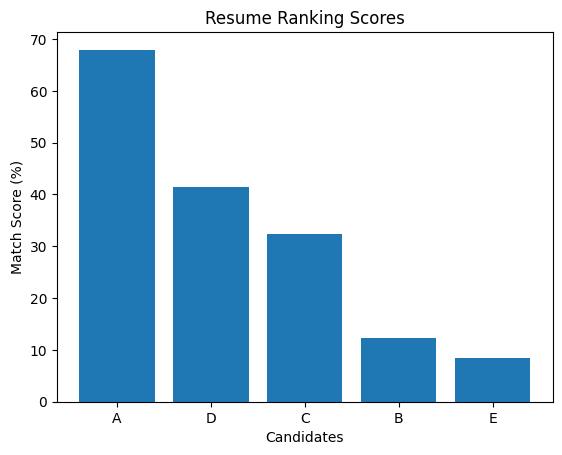

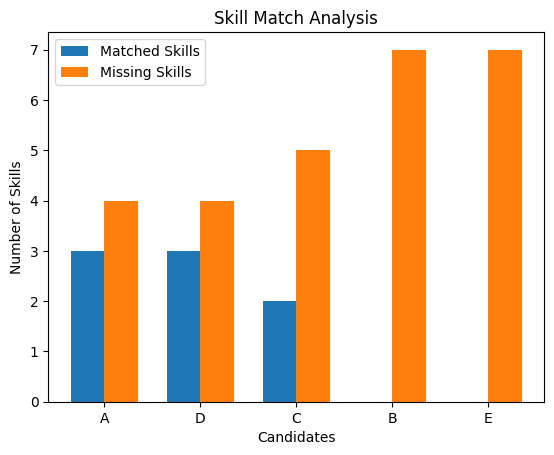


=== TOP CANDIDATE ===
Name: A
Score: 67.94%
Matched Skills: ['python', 'machine learning', 'data analysis']
Missing Skills: ['sql', 'nlp', 'deep learning', 'api']


In [2]:
# ==========================================
# 1. Install Libraries
# ==========================================
!pip install pandas scikit-learn matplotlib

# ==========================================
# 2. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 3. Job Description
# ==========================================
job_description = """
Looking for a Python Developer with experience in machine learning,
data analysis, SQL, NLP, deep learning, and APIs.
"""

required_skills = [
    "python", "machine learning", "data analysis",
    "sql", "nlp", "deep learning", "api"
]

# ==========================================
# 4. Resumes
# ==========================================
resumes = [
    "Python developer with machine learning and data analysis experience",
    "Frontend developer skilled in HTML CSS JavaScript",
    "Data analyst with SQL Python and dashboards",
    "ML engineer with deep learning NLP and API experience",
    "Java developer with problem solving skills"
]

names = ["A", "B", "C", "D", "E"]

# ==========================================
# 5. Clean Text
# ==========================================
def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

resumes_clean = [clean(r) for r in resumes]
job_clean = clean(job_description)

# ==========================================
# 6. TF-IDF + Similarity
# ==========================================
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(resumes_clean + [job_clean])

scores = cosine_similarity(tfidf[:-1], tfidf[-1])

# ==========================================
# 7. Skill Matching
# ==========================================
def match_skills(resume):
    matched = [s for s in required_skills if s in resume]
    missing = [s for s in required_skills if s not in resume]
    return matched, missing

results = []

for i, res in enumerate(resumes_clean):
    matched, missing = match_skills(res)

    results.append({
        "Name": names[i],
        "Score": round(scores[i][0]*100,2),
        "Matched": len(matched),
        "Missing": len(missing),
        "Matched Skills": matched,
        "Missing Skills": missing
    })

# Sort
results = sorted(results, key=lambda x: x["Score"], reverse=True)

df = pd.DataFrame(results)

print("\n=== RANKING ===\n")
print(df)

# ==========================================
# 8. VISUALIZATION 1: Candidate Scores
# ==========================================
plt.figure()
plt.bar(df["Name"], df["Score"])
plt.title("Resume Ranking Scores")
plt.xlabel("Candidates")
plt.ylabel("Match Score (%)")
plt.show()

# ==========================================
# 9. VISUALIZATION 2: Skill Match vs Missing
# ==========================================
plt.figure()

x = np.arange(len(df))
width = 0.35

plt.bar(x - width/2, df["Matched"], width, label="Matched Skills")
plt.bar(x + width/2, df["Missing"], width, label="Missing Skills")

plt.xticks(x, df["Name"])
plt.xlabel("Candidates")
plt.ylabel("Number of Skills")
plt.title("Skill Match Analysis")
plt.legend()

plt.show()

# ==========================================
# 10. Highlight Top Candidate
# ==========================================
top = df.iloc[0]

print("\n=== TOP CANDIDATE ===")
print(f"Name: {top['Name']}")
print(f"Score: {top['Score']}%")
print(f"Matched Skills: {top['Matched Skills']}")
print(f"Missing Skills: {top['Missing Skills']}")